# `jlegroup.shadowmap` — occultation shadow maps

Where on Earth will an occultation be visible? `shadowmap` draws the classic planning
product: the hemisphere of the Earth **as seen from the occulting body**, with coastlines,
night-side shading, and the shadow track — the band swept across the Earth by the body's
shadow — plus mercator/equirectangular variants with properly re-projected ground tracks.

It implements the functionality of the Mathematica `jleGroup`shadowMap`` package (4.1.4)
with modern machinery: **astropy** for all time and coordinate work (`Time`, `SkyCoord` →
ITRS, `get_sun`), the public-domain **Natural Earth** 1:110m coastlines bundled as package
data, and a night terminator that is exact for the spherical-Earth model (the original
package's night shading carried a longstanding placement defect — see the module docstring
and `tests/data/shadowmap-mathematica/README.md`).

**Demo event: the 2015 June 29 Pluto occultation.** A week before the New Horizons flyby,
Pluto occulted a ~12th-magnitude star; the shadow crossed New Zealand and southeast
Australia in local night, and SOFIA flew into the central-flash zone. We use it throughout.

> The star position and closest-approach geometry below are **illustrative values of the
> right scale** for this event, not a reconstructed prediction — for research use, take the
> star from Gaia and the geometry (impact parameter, position angle, mid-time, velocity)
> from your prediction pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jlegroup
from jlegroup import physicalData, shadowmap as sm

print("jlegroup", jlegroup.__version__)

jlegroup 0.11.0


## 1. Star, time, and the special points

Inputs are flexible: the star is anything `star_coord` understands — an astropy `SkyCoord`
in any frame (the natural modern input: your Gaia position), a single `"HH MM SS ±DD MM SS"`
string, or separate sexagesimal strings / degree floats.  Times go through `as_time`:
astropy `Time`, MJD floats, ISO strings, or the legacy jleGroup `"YYYY:MM:DD:HH:MM:SS"`
form.

The **sub-star point** — where the star is at the zenith, the center of the shadow-map view —
is the star direction transformed to the Earth-fixed ITRS frame (precession, nutation,
aberration, and Earth rotation handled by astropy; the Mathematica original approximated
this with mean GMST and apparent-of-date coordinates).

In [2]:
star = sm.star_coord("19 00 49.5 -20 41 41")     # ~ the 2015-06-29 star (ICRS)
t = sm.as_time("2015-06-29 16:55:00")            # mid-event, UT

# equivalent inputs:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
same_star = SkyCoord(ra=star.ra, dec=star.dec)               # a Gaia-style SkyCoord
assert sm.as_time(57202.70486111111).mjd == sm.as_time("2015:06:29:16:55:00").mjd

view_lat, view_lon = sm.substar_point(star, t)
sun_lat, sun_lon = sm.subsolar_point(t)
anti_lat, anti_lon = sm.antisolar_point(t)
print(f"sub-star  point: lat {view_lat:7.2f}, e.lon {view_lon:8.2f}   (view center)")
print(f"sub-solar point: lat {sun_lat:7.2f}, e.lon {sun_lon:8.2f}   (local noon)")
print(f"antisolar point: lat {anti_lat:7.2f}, e.lon {anti_lon:8.2f}   (center of night)")

sub-star  point: lat  -20.67, e.lon   114.24   (view center)
sub-solar point: lat   23.21, e.lon   -72.88   (local noon)
antisolar point: lat  -23.21, e.lon   107.12   (center of night)


## 2. Fundamental-plane geometry

The shadow track is drawn in the **fundamental plane** — the plane through the geocenter
perpendicular to the star direction — in Earth radii.  Three numbers place it:

* `dist` — closest-approach offset of the shadow **center** from the geocenter.
  `dist_from_impact_parameter` (the old `smDist`) converts a prediction's impact parameter
  in arcsec at the body's geocentric distance in au;
* `pa` — the position angle of the body relative to the star at closest approach
  (degrees, north through east);
* `radius` — the occulting body's radius in Earth radii (the shadow band's half-width).

Earth's radius (IAU-1976, 6378.14 km — what the original hardcoded) comes from
`physicalData.BODIES["Earth"]`; the au is `physicalData.AU_KM`.

In [3]:
b_arcsec, d_au = 0.083, 31.9                 # illustrative closest approach
dist = sm.dist_from_impact_parameter(b_arcsec, d_au)

r_pluto_km = 1188.3                          # New Horizons radius, demo parameter
radius = r_pluto_km / physicalData.BODIES["Earth"].radius_km

pa = 196.0                                   # deg, N through E (illustrative)
pred_error = 0.10                            # 1-sigma cross-track, Earth radii

print(f"impact parameter {b_arcsec}\" at {d_au} au  ->  dist = {dist:.3f} Earth radii")
print(f"Pluto radius {r_pluto_km} km            ->  radius = {radius:.3f} Earth radii")

impact parameter 0.083" at 31.9 au  ->  dist = 0.301 Earth radii
Pluto radius 1188.3 km            ->  radius = 0.186 Earth radii


## 3. The map: Earth as seen from Pluto

`globe` is the one-call product (the old `smGlobe`).  Orthographic convention: **north up,
east right, unit Earth radius** — exactly the view from the incoming shadow.  The gray
region is night (`horizon_angle` degrees of sun depression; 0 = geometric terminator).
Solid lines: the two shadow-band edges and its center; dashed: the ±1σ cross-track
prediction error.

Note how much of the star-facing hemisphere is dark: Pluto was a week from opposition, and
opposition geometry is exactly what makes an occultation observable — the shadow lands on
the night side.

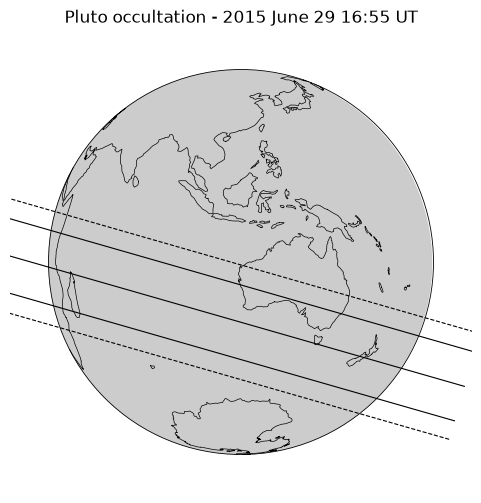

In [4]:
ax = sm.globe(star, t, tracks=True, dist=dist, pa=pa, radius=radius,
              pred_error=pred_error, horizon_angle=0.0, print_diagnostic=True,
              plot_label="Pluto occultation - 2015 June 29 16:55 UT")
plt.show()

## 4. Three projections, one geometry

Cylindrical maps (in **view-frame** coordinates — the sub-star meridian at x = 0) carry the
same information with the whole Earth visible.  On these, the straight fundamental-plane
lines are meaningless, so `globe` draws the **ground tracks** instead: each shadow line's
on-disk chord lifted to the Earth's surface (`track_ground_paths`), re-projected — the
familiar curved paths of published occultation maps.  Lines that miss the Earth simply have
no ground track.

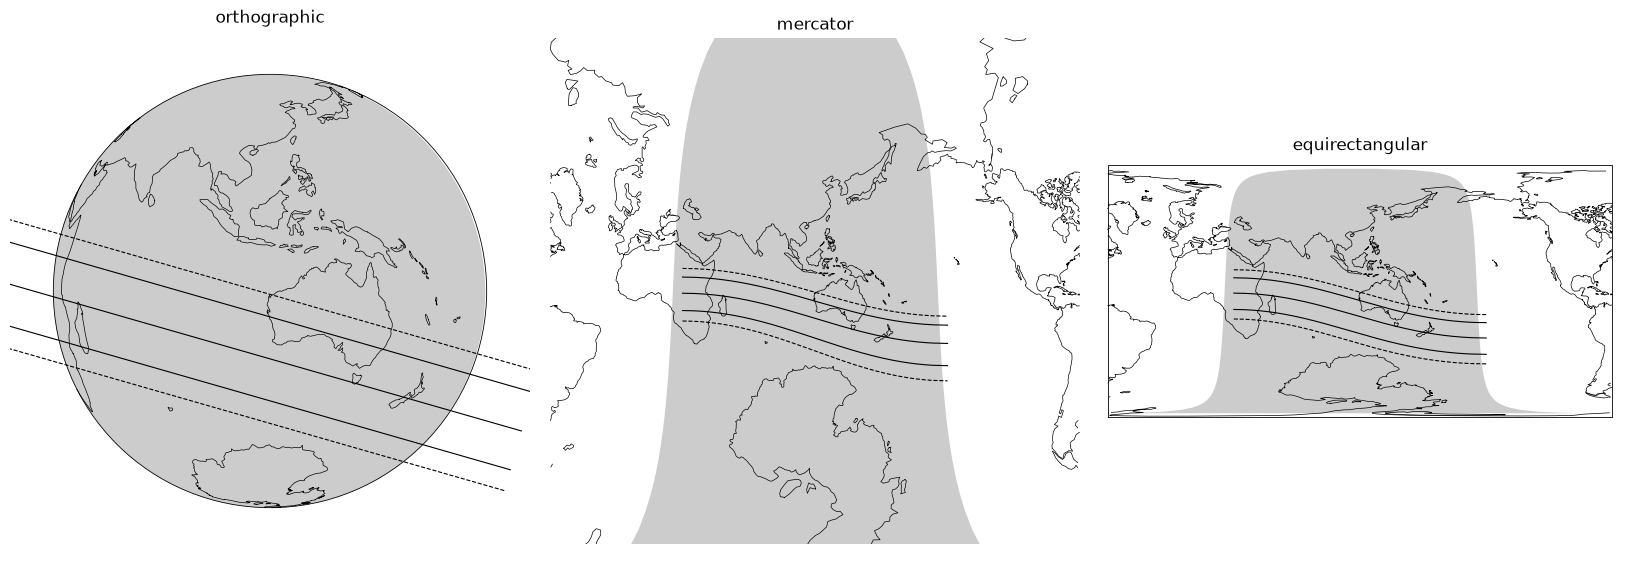

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.5))
for ax, proj in zip(axes, sm.PROJECTIONS):
    sm.globe(star, t, ax=ax, projection=proj, tracks=True, dist=dist, pa=pa,
             radius=radius, pred_error=pred_error, plot_label=proj)
fig.tight_layout()
plt.show()

## 5. The ground path in geographic coordinates

`track_ground_paths` returns the path curves in view-frame (lat′, lon′);
`view_rotation_inverse` turns them into geographic latitude/longitude — the actual
predicted path on the ground, something the Mathematica package never exposed.  Here: the
center line comes ashore over southeast Australia and crosses New Zealand — where the
2015 event was in fact observed.

In [6]:
paths = sm.track_ground_paths(dist=dist, pa_deg=pa, radius=radius,
                              pred_error=pred_error)
lat, lon = sm.view_rotation_inverse(paths.center[:, 0], paths.center[:, 1],
                                    view_lat, view_lon)
lat_deg, lon_deg = np.degrees(lat), (np.degrees(lon) + 180.0) % 360.0 - 180.0

order = np.argsort(lon_deg)
print(f"shadow-center ground path: {len(lat_deg)} samples, limb to limb")
for name, target in [("SE Australia   (147 E)", 147.0),
                     ("NZ South Island (168 E)", 168.0),
                     ("NZ North Island (175 E)", 175.0)]:
    print(f"  crosses {name} at lat "
          f"{np.interp(target, lon_deg[order], lat_deg[order]):6.1f}")

shadow-center ground path: 181 samples, limb to limb
  crosses SE Australia   (147 E) at lat  -43.3
  crosses NZ South Island (168 E) at lat  -42.8
  crosses NZ North Island (175 E) at lat  -42.1


## 6. Twilight depth

`horizon_angle` sets how far the sun must be below the geometric horizon for a point to be
shaded — 6/12/18° are civil/nautical/astronomical darkness.  (Refraction is not modeled;
fold ~0.57° into `horizon_angle` if you care.)  The boundary drawn is exact: every point of
it sits at sun altitude `-horizon_angle` to machine precision of the spherical model —
that invariant is part of the test suite.

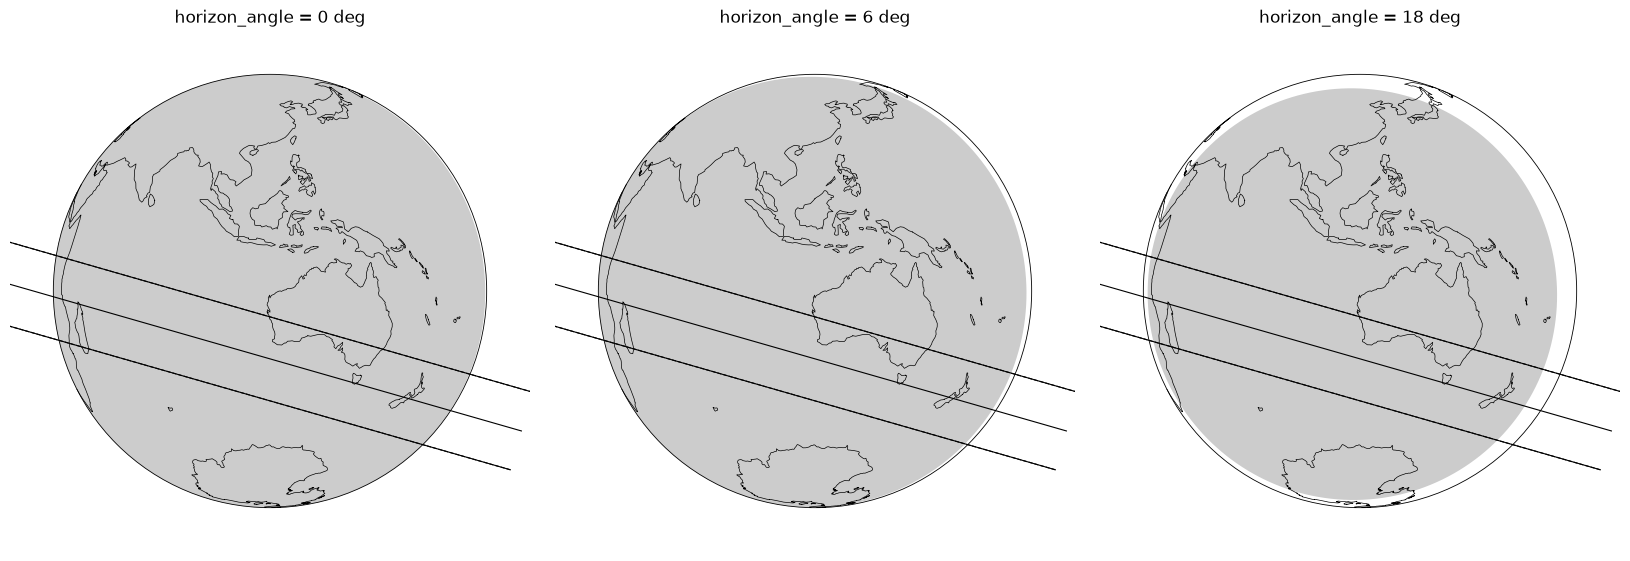

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.5))
for ax, h in zip(axes, (0.0, 6.0, 18.0)):
    sm.globe(star, t, ax=ax, horizon_angle=h, tracks=True, dist=dist, pa=pa,
             radius=radius, plot_label=f"horizon_angle = {h:.0f} deg")
fig.tight_layout()
plt.show()

## 7. Updating a prediction: `offset_prediction`

The old `smOffset` workflow: a late astrometric update moves the star (or equivalently the
ephemeris) — revise the impact parameter, position angle, and mid-time without re-running
the full search, assuming linear relative motion.  Offsets can be sexagesimal strings (RA
in *hours*, as in the original), astropy `Angle`s/`Quantity`s, or floats in degrees.
Pluto's apparent motion was retrograde (a week before opposition), hence
`retrograde=True`.

In [8]:
from astropy import units as u

update = sm.offset_prediction(
    "19 00 49.5", "-20 41 41",
    ra_offset=30 * u.mas, dec_offset=-45 * u.mas,   # the astrometric update
    b_arcsec=b_arcsec, pa_deg=pa, time=t,
    sky_velocity_kms=24.2, distance_au=d_au,
    retrograde=True)

print("revised star :", update.ra_string, update.dec_string)
print("revised time :", update.date_string, " (shift",
      f"{(update.time - t).to_value(u.s):+.1f} s)")
print(f"revised b    : {update.b_arcsec:.4f} arcsec "
      f"->  dist = {sm.dist_from_impact_parameter(update.b_arcsec, d_au):.3f} Earth radii")
print(f"revised PA   : {update.pa_deg:.2f} deg")

revised star : 19 00 49.4980 -20 41 40.9550
revised time : 2015-06-29 16:54:22.350  (shift -37.6 s)
revised b    : 0.1185 arcsec ->  dist = 0.430 Earth radii
revised PA   : 196.00 deg


## 8. Trust check

The night shading is validated by physics, not by the original package (whose shading was
misplaced whenever the star and the sun were both off the equator): rotate the drawn
terminator back to geographic coordinates and evaluate the true geocentric sun altitude
there — it must equal `-horizon_angle` everywhere.

In [9]:
from astropy.coordinates import ITRS, get_sun

h = 12.0
poly = sm.night_polygon(view_lat, view_lon, anti_lat, anti_lon, h,
                        "equirectangular")
plat, plon = sm.view_rotation_inverse(poly[:, 1], poly[:, 0], view_lat, view_lon)
sun = get_sun(t).transform_to(ITRS(obstime=t)).spherical
sinalt = (np.sin(plat) * np.sin(sun.lat.to_value(u.rad))
          + np.cos(plat) * np.cos(sun.lat.to_value(u.rad))
          * np.cos(plon - sun.lon.to_value(u.rad)))
alt = np.degrees(np.arcsin(np.clip(sinalt, -1, 1)))
print(f"drawn terminator (h = {h}): sun altitude "
      f"{alt.min():.9f} .. {alt.max():.9f} deg   (target {-h})")

drawn terminator (h = 12.0): sun altitude -12.000000000 .. -12.000000000 deg   (target -12.0)


## Notes

* **Model**: spherical Earth (geocentric latitudes), geometric horizon, geocentric apparent
  sun — the display model of the original package, adequate for planning maps.  Earth
  rotation accuracy follows your astropy IERS configuration (offline or far-future dates
  degrade gracefully; see `astropy.utils.iers`).
* **Coastlines**: Natural Earth 1:110m (public domain), bundled — no runtime downloads.
* **Provenance**: geometry, track construction, and the `smDist`/`smOffset` methods are
  ported from Mathematica `jleGroup`shadowMap`` 4.1.4 and validated against reference
  output generated by running the original (`tests/data/shadowmap-mathematica/`); astropy
  supersedes its time/GMST/solar theory.  There is no reference publication for this
  module — the package is the reference implementation.  See the module docstring for the
  full story, including the two defects of the original that are corrected here.